In [61]:
!pip install tensorly

In [62]:
import numpy as np
import os
import tensorly as tl
from tensorly.decomposition import parafac2


base_path = "data"

X_list = []

for i in range(1, 101):
    filename = f"kh{i:03d}_sparse.npy"
    filepath = os.path.join(base_path, filename)

    if not os.path.exists(filepath):
        continue

    data = np.load(filepath)

    # Keep only active clusters (non-zero columns)
    active_clusters = np.where(np.any(data != 0, axis=0))[0]

    if len(active_clusters) == 0:
        continue

    X_k = data[:, active_clusters]          # currently (time, C_k)

    # === FIX: Transpose so channels are on rows ===
    X_k = X_k.T                             # now shape (C_k, time) = (varying, 6000)

    # Optional: normalize per time point (or per channel — your choice)
    # Here: centering and scaling each time point across channels
    X_k = (X_k - np.median(X_k, axis=1, keepdims=True)) / (
            np.std(X_k, axis=1, keepdims=True) + 1e-8
    )

    X_list.append(X_k.astype(np.float64))   # good to use float64

print(f"Loaded {len(X_list)} subjects")

Loaded 96 subjects


In [63]:
target_T = 6000

X_list = [X_k for X_k in X_list if X_k.shape[1] == target_T]


In [73]:
min_channels = min(X.shape[0] for X in X_list)
max_channels = max(X.shape[0] for X in X_list)
print(f"Number of patients: {len(X_list)}")
print(f"Channels per patient — min: {min_channels}, max: {max_channels}")

# Show the worst patients
worst_patients = sorted(enumerate(X_list), key=lambda x: x[1].shape[0])[:5]
for i, X in worst_patients:
    print(f"Patient {i:2d}: {X.shape[0]} channels")

Number of patients: 92
Channels per patient — min: 15, max: 85
Patient 56: 15 channels
Patient  4: 17 channels
Patient 16: 19 channels
Patient 10: 25 channels
Patient 48: 25 channels


In [64]:
print(len(X_list))

for matrix in X_list:
    print(matrix.shape)

92
(52, 6000)
(55, 6000)
(58, 6000)
(59, 6000)
(17, 6000)
(50, 6000)
(33, 6000)
(49, 6000)
(65, 6000)
(60, 6000)
(25, 6000)
(29, 6000)
(52, 6000)
(50, 6000)
(71, 6000)
(67, 6000)
(19, 6000)
(68, 6000)
(71, 6000)
(63, 6000)
(66, 6000)
(84, 6000)
(69, 6000)
(33, 6000)
(45, 6000)
(72, 6000)
(74, 6000)
(55, 6000)
(47, 6000)
(34, 6000)
(62, 6000)
(67, 6000)
(67, 6000)
(48, 6000)
(68, 6000)
(60, 6000)
(38, 6000)
(44, 6000)
(59, 6000)
(54, 6000)
(34, 6000)
(49, 6000)
(36, 6000)
(55, 6000)
(61, 6000)
(37, 6000)
(38, 6000)
(35, 6000)
(25, 6000)
(71, 6000)
(69, 6000)
(26, 6000)
(69, 6000)
(53, 6000)
(51, 6000)
(36, 6000)
(15, 6000)
(45, 6000)
(53, 6000)
(46, 6000)
(29, 6000)
(61, 6000)
(58, 6000)
(57, 6000)
(60, 6000)
(67, 6000)
(66, 6000)
(68, 6000)
(53, 6000)
(39, 6000)
(63, 6000)
(58, 6000)
(39, 6000)
(61, 6000)
(47, 6000)
(52, 6000)
(36, 6000)
(60, 6000)
(52, 6000)
(65, 6000)
(49, 6000)
(80, 6000)
(64, 6000)
(48, 6000)
(52, 6000)
(66, 6000)
(72, 6000)
(85, 6000)
(71, 6000)
(56, 6000)
(71, 60

In [74]:
rank = 15

decomposition = parafac2(
    X_list,
    rank=rank,
    n_iter_max=3000,          # give it more room
    init='svd',               # much better than 'random' — strongly recommended
    svd='truncated_svd',
    tol=1e-7,
    random_state=None,        # try different seeds if needed
    verbose=True,
    linesearch=True,          # helps convergence
)


Starting iteration 0
reconstruction error=0.9130583523803063
iteration 1, reconstruction error: 0.8923366209301662, decrease = 0.020721731450140113, unnormalized = 3630.6463684750283
iteration 2, reconstruction error: 0.881629424052372, decrease = 0.0107071968777942, unnormalized = 3587.0820402281515
iteration 3, reconstruction error: 0.8786779834333217, decrease = 0.002951440619050283, unnormalized = 3575.0735258245236
iteration 4, reconstruction error: 0.8777495536887043, decrease = 0.0009284297446173762, unnormalized = 3571.296027510977
PARAFAC2 reconstruction error=0.9347299417420137
Starting iteration 1
reconstruction error=0.8709485957751254
iteration 1, reconstruction error: 0.8707829781689201, decrease = 0.00016561760620525945, unnormalized = 3539.1567365113497
iteration 2, reconstruction error: 0.8707338181051254, decrease = 4.9160063794739806e-05, unnormalized = 3538.9569333740487
iteration 3, reconstruction error: 0.8707124711595506, decrease = 2.13469455747628e-05, unnormal

In [75]:
from tensorly.parafac2_tensor import parafac2_to_slices

# Option 2 (usually more useful): List of reconstructed slices with original shapes
reconstructed_slices = parafac2_to_slices(decomposition)

print(f"Number of reconstructed slices: {len(reconstructed_slices)}")
for i, mat in enumerate(reconstructed_slices):
    print(f"Subject {i} reconstructed shape: {mat.shape}")   # should match original X_list[i].shape



Number of reconstructed slices: 92
Subject 0 reconstructed shape: (52, 6000)
Subject 1 reconstructed shape: (55, 6000)
Subject 2 reconstructed shape: (58, 6000)
Subject 3 reconstructed shape: (59, 6000)
Subject 4 reconstructed shape: (17, 6000)
Subject 5 reconstructed shape: (50, 6000)
Subject 6 reconstructed shape: (33, 6000)
Subject 7 reconstructed shape: (49, 6000)
Subject 8 reconstructed shape: (65, 6000)
Subject 9 reconstructed shape: (60, 6000)
Subject 10 reconstructed shape: (25, 6000)
Subject 11 reconstructed shape: (29, 6000)
Subject 12 reconstructed shape: (52, 6000)
Subject 13 reconstructed shape: (50, 6000)
Subject 14 reconstructed shape: (71, 6000)
Subject 15 reconstructed shape: (67, 6000)
Subject 16 reconstructed shape: (19, 6000)
Subject 17 reconstructed shape: (68, 6000)
Subject 18 reconstructed shape: (71, 6000)
Subject 19 reconstructed shape: (63, 6000)
Subject 20 reconstructed shape: (66, 6000)
Subject 21 reconstructed shape: (84, 6000)
Subject 22 reconstructed shap

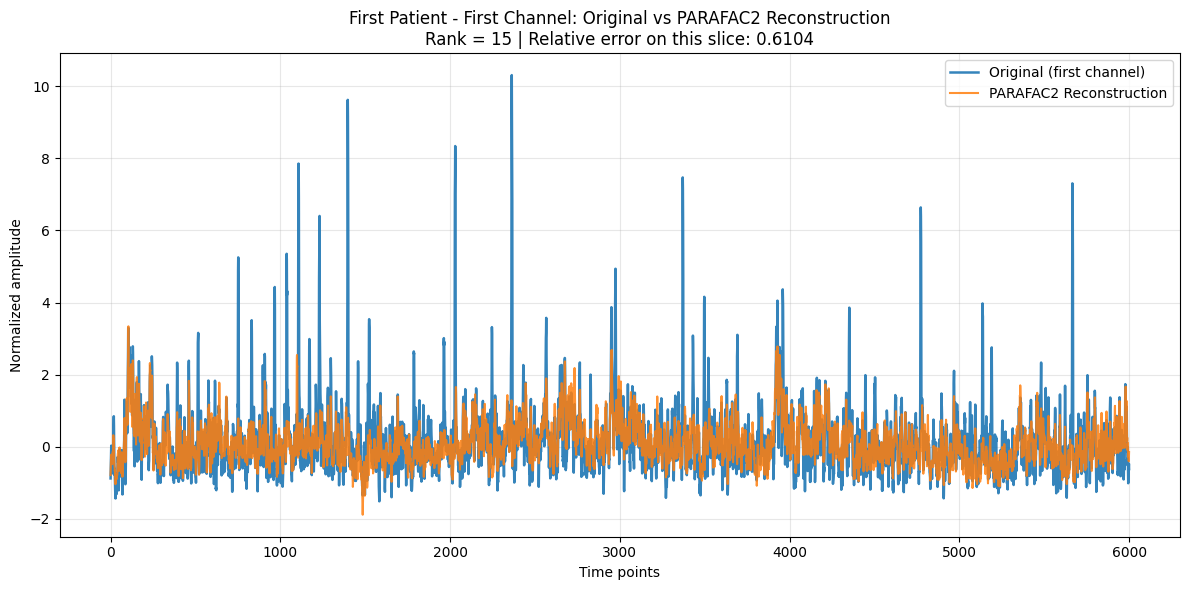

In [76]:
from matplotlib import pyplot as plt

# 2. Take first patient (index 0)
orig_first_patient = X_list[9]           # shape: (n_channels_0, 6000)
rec_first_patient  = reconstructed_slices[9]

# 3. Take the first channel (first row)
orig_channel = orig_first_patient[2, :]   # shape: (6000,)
rec_channel  = rec_first_patient[2, :]

# 4. Plot comparison
time = np.arange(6000)   # or np.arange(orig_channel.shape[0]) if not exactly 6000

plt.figure(figsize=(12, 6))

plt.plot(time, orig_channel, label='Original (first channel)', linewidth=1.8, alpha=0.9)
plt.plot(time, rec_channel,  label='PARAFAC2 Reconstruction', linewidth=1.5, alpha=0.85)

plt.title('First Patient - First Channel: Original vs PARAFAC2 Reconstruction\n'
          f'Rank = {rank} | Relative error on this slice: '
          f'{np.linalg.norm(orig_first_patient - rec_first_patient) / np.linalg.norm(orig_first_patient):.4f}')

plt.xlabel('Time points')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

# Optional: zoom on first 1000 points if you want to see details
# plt.xlim(0, 1000)

plt.tight_layout()
plt.show()

In [77]:
reconstructed_slices = parafac2_to_slices(decomposition)

per_patient_errors = []
for i, (orig, rec) in enumerate(zip(X_list, reconstructed_slices)):
    rel_err = np.linalg.norm(orig - rec) / (np.linalg.norm(orig) + 1e-8)
    per_patient_errors.append(rel_err)
    if rel_err > 0.5:   # flag very bad ones
        print(f"Patient {i}: relative error = {rel_err:.4f} | shape = {orig.shape}")

print(f"Mean per-patient error: {np.mean(per_patient_errors):.4f}")
print(f"Max per-patient error: {np.max(per_patient_errors):.4f}")

Patient 1: relative error = 0.6467 | shape = (55, 6000)
Patient 3: relative error = 0.8881 | shape = (59, 6000)
Patient 4: relative error = 0.9899 | shape = (17, 6000)
Patient 5: relative error = 0.9877 | shape = (50, 6000)
Patient 6: relative error = 0.9616 | shape = (33, 6000)
Patient 7: relative error = 0.7974 | shape = (49, 6000)
Patient 8: relative error = 0.9865 | shape = (65, 6000)
Patient 9: relative error = 0.6104 | shape = (60, 6000)
Patient 10: relative error = 0.9832 | shape = (25, 6000)
Patient 11: relative error = 0.9886 | shape = (29, 6000)
Patient 12: relative error = 0.8892 | shape = (52, 6000)
Patient 13: relative error = 0.9561 | shape = (50, 6000)
Patient 14: relative error = 0.9845 | shape = (71, 6000)
Patient 15: relative error = 0.9701 | shape = (67, 6000)
Patient 16: relative error = 0.9563 | shape = (19, 6000)
Patient 17: relative error = 0.9762 | shape = (68, 6000)
Patient 18: relative error = 0.9824 | shape = (71, 6000)
Patient 19: relative error = 0.9791 | s